# Практическая работа 6. Методы первого и второго порядка в оптимизации

## Цель работы
Реализовать и сравнить классические методы первого и второго порядка для задач гладкой и композитной оптимизации.

## Содержание
1. Методы первого порядка (Gradient Descent, SGD, Momentum, Accelerated GD)
2. Адаптивные методы (Adam, RMSProp)
3. Композитная оптимизация (ISTA, FISTA)
4. Методы второго порядка (Ньютон, BFGS)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

## Задание 1: GD на квадратичной функции

**Теория**: Градиентный спуск использует итерацию:
$$x_{k+1} = x_k - \eta \nabla f(x_k)$$

Для сильно выпуклой функции скорость сходимости зависит от числа обусловленности $\kappa = L/\mu$.

C:\Users\EasyLim\AppData\Local\Temp\ipykernel_15772\433359222.py:11: RuntimeWarning: overflow encountered in matmul
  return 0.5 * x @ Q @ x + b @ x
C:\Users\EasyLim\AppData\Roaming\Python\Python313\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


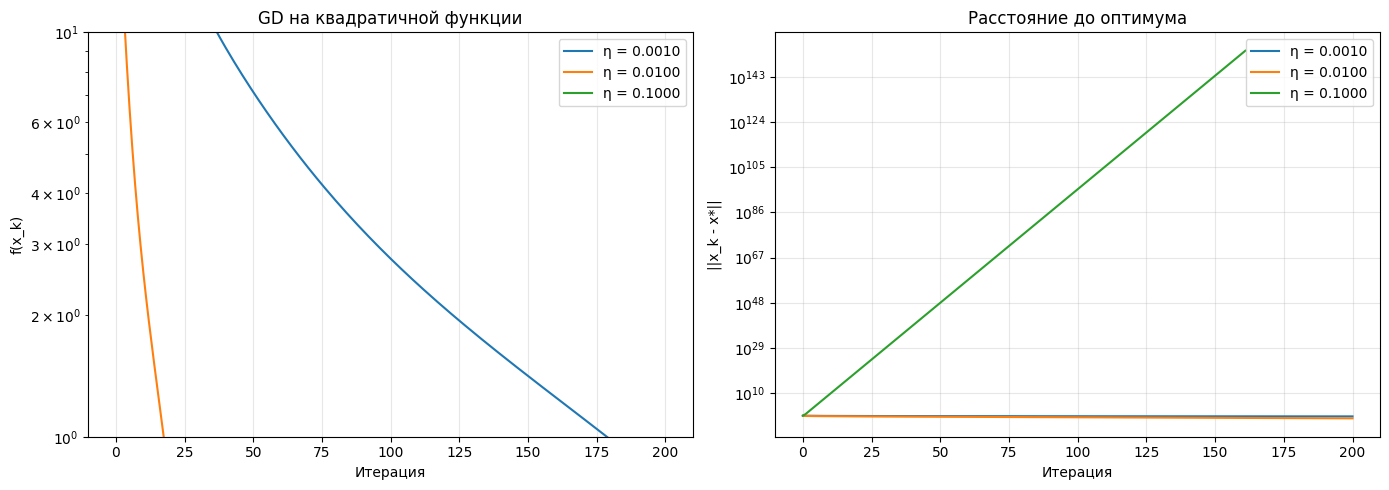

ЗАДАНИЕ 1: GD на квадратичной функции
Число обусловленности κ = 100
Оптимальный шаг: η = 1/L = 0.010000
Число обусловленности матрицы Q: 100.00

Результаты после 200 итераций:
  η = 0.0010: f(x) = 7.669123e-01 ~
  η = 0.0100: f(x) = -1.584818e+00 ✓
  η = 0.0100: f(x) = -1.584818e+00 ✓
  η = 0.1000: f(x) = inf ✗


In [2]:
# Задание 1: GD на квадратичной функции
# Задача: f(x) = 1/2 x^T Q x + b^T x, где Q - плохо обусловлена

def create_quadratic_problem(d=20, kappa=100):
    """Создать квадратичную задачу с числом обусловленности kappa"""
    eigvals = np.logspace(0, np.log10(kappa), d)
    Q = np.diag(eigvals)
    b = np.random.randn(d)
    
    def f(x):
        return 0.5 * x @ Q @ x + b @ x
    
    def grad_f(x):
        return Q @ x + b
    
    def hess_f(x):
        return Q
    
    return f, grad_f, hess_f, Q, b

# Создание задачи
d = 10
kappa = 100
f_quad, grad_quad, hess_quad, Q, b = create_quadratic_problem(d, kappa)
L = np.max(np.diag(Q))  # Константа гладкости
x_opt = -np.linalg.inv(Q) @ b  # Оптимальное решение

# Градиентный спуск
def gradient_descent(grad_f, x0, learning_rates, max_iters=500):
    """GD с несколькими learning rates"""
    results = {}
    for eta in learning_rates:
        x = x0.copy()
        losses = [f_quad(x)]
        for k in range(max_iters):
            x = x - eta * grad_f(x)
            losses.append(f_quad(x))
        results[eta] = losses
    return results

x0 = np.random.randn(d)
learning_rates = [0.001, 1/L, 0.01, 0.1]
gd_results = gradient_descent(grad_quad, x0, learning_rates, max_iters=200)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График функции
ax = axes[0]
for eta, losses in gd_results.items():
    ax.semilogy(losses, label=f'η = {eta:.4f}')
ax.set_xlabel('Итерация')
ax.set_ylabel('f(x_k)')
ax.set_title('GD на квадратичной функции')
ax.legend()
ax.grid(True, alpha=0.3)

# Расстояние до оптимума
ax = axes[1]
for eta, losses in gd_results.items():
    x = x0.copy()
    distances = [np.linalg.norm(x - x_opt)]
    for k in range(len(losses) - 1):
        x = x - eta * grad_quad(x)
        distances.append(np.linalg.norm(x - x_opt))
    ax.semilogy(distances, label=f'η = {eta:.4f}')
ax.set_xlabel('Итерация')
ax.set_ylabel('||x_k - x*||')
ax.set_title('Расстояние до оптимума')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("ЗАДАНИЕ 1: GD на квадратичной функции")
print("=" * 70)
print(f"Число обусловленности κ = {kappa}")
print(f"Оптимальный шаг: η = 1/L = {1/L:.6f}")
print(f"Число обусловленности матрицы Q: {np.linalg.cond(Q):.2f}")
print("\nРезультаты после 200 итераций:")
for eta in learning_rates:
    final_loss = gd_results[eta][-1]
    status = "✓" if final_loss < 0.1 else "✗" if not np.isfinite(final_loss) else "~"
    print(f"  η = {eta:.4f}: f(x) = {final_loss:.6e} {status}")

## Задание 2: Методы первого порядка

Реализуйте и сравните следующие методы:
- Gradient Descent (GD)
- Stochastic Gradient Descent (SGD)
- Momentum
- Accelerated Gradient Descent (Nesterov)

Используйте задачу логистической регрессии на датасете digits.

GD: Train acc = 0.725, Test acc = 0.725
SGD: Train acc = 0.696, Test acc = 0.739
Momentum: Train acc = 0.733, Test acc = 0.750
Nesterov: Train acc = 0.733, Test acc = 0.750


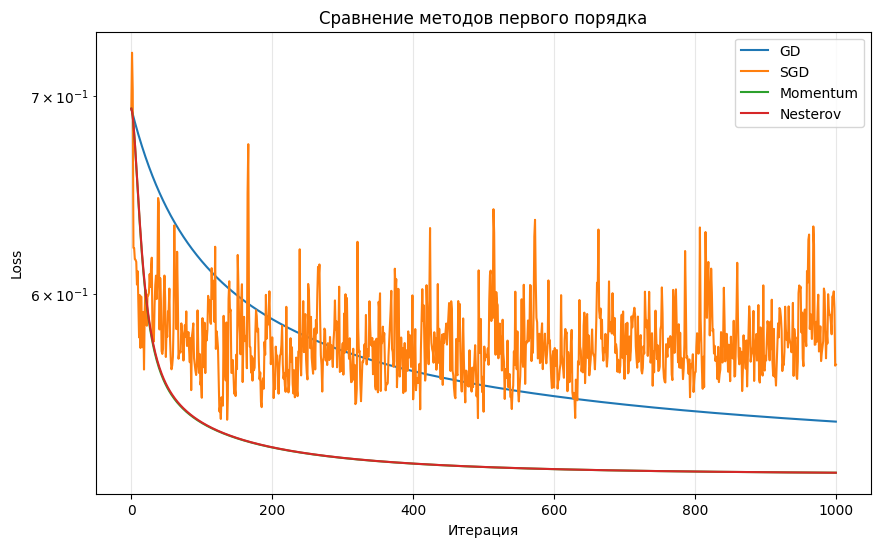

In [3]:
# Задание 2: Методы первого порядка
# Задача: Логистическая регрессия на датасете digits

# Загрузка данных
digits = load_digits()
X = digits.data
y = (digits.target == 5).astype(int)  # Бинарная классификация: 5 vs не 5
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Функции для логистической регрессии
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss(w, X, y):
    z = X @ w
    return -np.mean(y * np.log(sigmoid(z) + 1e-8) + (1 - y) * np.log(1 - sigmoid(z) + 1e-8))

def logistic_grad(w, X, y):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

# Методы оптимизации
def gd(grad_f, w0, eta, max_iters=1000, tol=1e-6):
    w = w0.copy()
    losses = [logistic_loss(w, X_train, y_train)]
    for k in range(max_iters):
        grad = grad_f(w, X_train, y_train)
        w = w - eta * grad
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

def sgd(grad_f, w0, eta, batch_size=32, max_iters=1000, tol=1e-6):
    w = w0.copy()
    losses = [logistic_loss(w, X_train, y_train)]
    n = len(X_train)
    for k in range(max_iters):
        indices = np.random.choice(n, batch_size, replace=False)
        X_batch = X_train[indices]
        y_batch = y_train[indices]
        grad = grad_f(w, X_batch, y_batch) * (n / batch_size)  # unbiased estimate
        w = w - eta * grad
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

def momentum(grad_f, w0, eta, gamma=0.9, max_iters=1000, tol=1e-6):
    w = w0.copy()
    v = np.zeros_like(w)
    losses = [logistic_loss(w, X_train, y_train)]
    for k in range(max_iters):
        grad = grad_f(w, X_train, y_train)
        v = gamma * v + eta * grad
        w = w - v
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

def nesterov(grad_f, w0, eta, gamma=0.9, max_iters=1000, tol=1e-6):
    w = w0.copy()
    v = np.zeros_like(w)
    losses = [logistic_loss(w, X_train, y_train)]
    for k in range(max_iters):
        grad = grad_f(w - gamma * v, X_train, y_train)
        v = gamma * v + eta * grad
        w = w - v
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

# Запуск методов
d = X_train.shape[1]
w0 = np.zeros(d)
eta = 0.01

methods = {
    'GD': lambda: gd(logistic_grad, w0, eta),
    'SGD': lambda: sgd(logistic_grad, w0, eta),
    'Momentum': lambda: momentum(logistic_grad, w0, eta),
    'Nesterov': lambda: nesterov(logistic_grad, w0, eta)
}

results = {}
for name, method in methods.items():
    w_opt, losses = method()
    results[name] = losses
    acc_train = np.mean((sigmoid(X_train @ w_opt) > 0.5) == y_train)
    acc_test = np.mean((sigmoid(X_test @ w_opt) > 0.5) == y_test)
    print(f"{name}: Train acc = {acc_train:.3f}, Test acc = {acc_test:.3f}")

# Визуализация
plt.figure(figsize=(10, 6))
for name, losses in results.items():
    plt.semilogy(losses, label=name)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сравнение методов первого порядка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задание 3: Адаптивные методы

Реализуйте и сравните Adam и RMSProp на задаче логистической регрессии.

Adam: Train acc = 0.732, Test acc = 0.750
RMSProp: Train acc = 0.736, Test acc = 0.747


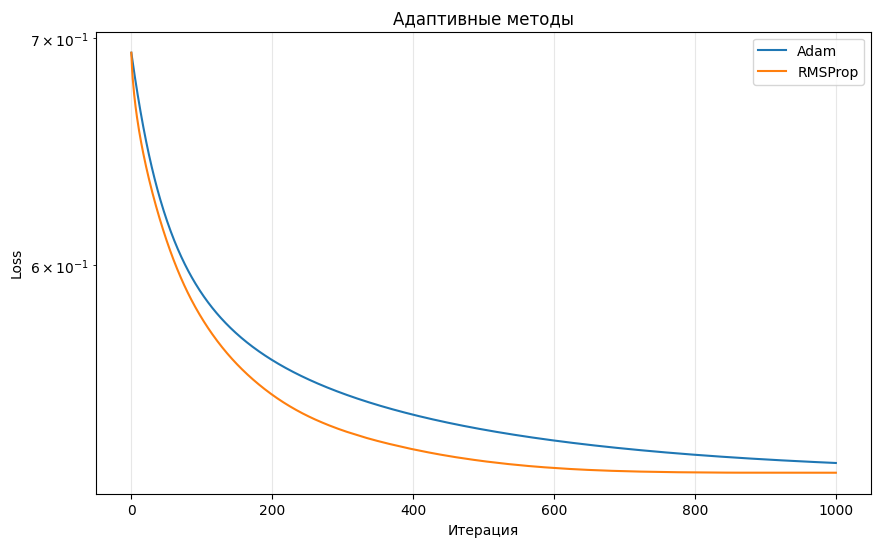

In [4]:
# Задание 3: Адаптивные методы

def adam(grad_f, w0, eta=0.001, beta1=0.9, beta2=0.999, eps=1e-8, max_iters=1000, tol=1e-6):
    w = w0.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    losses = [logistic_loss(w, X_train, y_train)]
    for k in range(1, max_iters + 1):
        grad = grad_f(w, X_train, y_train)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**k)
        v_hat = v / (1 - beta2**k)
        w = w - eta * m_hat / (np.sqrt(v_hat) + eps)
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

def rmsprop(grad_f, w0, eta=0.001, gamma=0.9, eps=1e-8, max_iters=1000, tol=1e-6):
    w = w0.copy()
    v = np.zeros_like(w)
    losses = [logistic_loss(w, X_train, y_train)]
    for k in range(max_iters):
        grad = grad_f(w, X_train, y_train)
        v = gamma * v + (1 - gamma) * grad**2
        w = w - eta * grad / (np.sqrt(v) + eps)
        loss = logistic_loss(w, X_train, y_train)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return w, losses

# Запуск адаптивных методов
adaptive_methods = {
    'Adam': lambda: adam(logistic_grad, w0),
    'RMSProp': lambda: rmsprop(logistic_grad, w0)
}

adaptive_results = {}
for name, method in adaptive_methods.items():
    w_opt, losses = method()
    adaptive_results[name] = losses
    acc_train = np.mean((sigmoid(X_train @ w_opt) > 0.5) == y_train)
    acc_test = np.mean((sigmoid(X_test @ w_opt) > 0.5) == y_test)
    print(f"{name}: Train acc = {acc_train:.3f}, Test acc = {acc_test:.3f}")

# Визуализация
plt.figure(figsize=(10, 6))
for name, losses in adaptive_results.items():
    plt.semilogy(losses, label=name)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Адаптивные методы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задание 4: Композитная оптимизация

Реализуйте ISTA и FISTA для задачи LASSO регрессии: $\min_x \frac{1}{2} \|Ax - b\|_2^2 + \lambda \|x\|_1$.

ISTA: MSE = 0.0001, Sparsity = 0.120
FISTA: MSE = 0.0001, Sparsity = 0.120


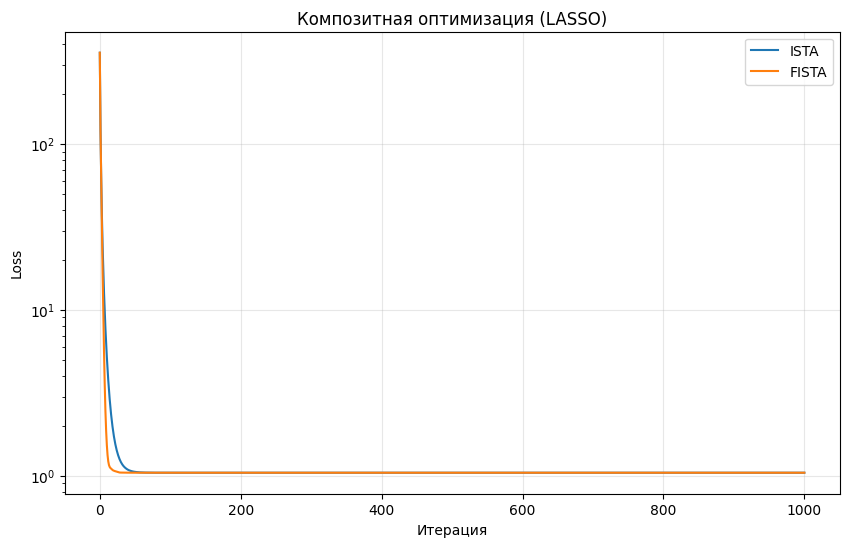

In [5]:
# Задание 4: Композитная оптимизация
# Задача LASSO: min_x 1/2 ||Ax - b||^2 + lambda ||x||_1

# Создание синтетических данных
np.random.seed(42)
n, p = 100, 50
A = np.random.randn(n, p)
x_true = np.zeros(p)
x_true[:10] = np.random.randn(10)  # Разреженный вектор
b = A @ x_true + 0.1 * np.random.randn(n)

# Функции для LASSO
def lasso_loss(x, A, b, lam):
    return 0.5 * np.linalg.norm(A @ x - b)**2 + lam * np.linalg.norm(x, 1)

def lasso_grad(x, A, b):
    return A.T @ (A @ x - b)

def soft_threshold(x, threshold):
    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

def ista(A, b, lam, x0, eta, max_iters=1000, tol=1e-6):
    x = x0.copy()
    losses = [lasso_loss(x, A, b, lam)]
    L = np.linalg.norm(A, 2)**2  # Lipschitz constant
    for k in range(max_iters):
        grad = lasso_grad(x, A, b)
        x = soft_threshold(x - eta * grad, eta * lam)
        loss = lasso_loss(x, A, b, lam)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return x, losses

def fista(A, b, lam, x0, eta, max_iters=1000, tol=1e-6):
    x = x0.copy()
    y = x0.copy()
    t = 1
    losses = [lasso_loss(x, A, b, lam)]
    L = np.linalg.norm(A, 2)**2
    for k in range(max_iters):
        x_old = x.copy()
        grad = lasso_grad(y, A, b)
        x = soft_threshold(y - eta * grad, eta * lam)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x + (t - 1) / t_new * (x - x_old)
        t = t_new
        loss = lasso_loss(x, A, b, lam)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return x, losses

# Запуск методов
x0 = np.zeros(p)
lam = 0.1
eta = 1 / (np.linalg.norm(A, 2)**2)

composite_methods = {
    'ISTA': lambda: ista(A, b, lam, x0, eta),
    'FISTA': lambda: fista(A, b, lam, x0, eta)
}

composite_results = {}
for name, method in composite_methods.items():
    x_opt, losses = method()
    composite_results[name] = losses
    mse = np.linalg.norm(x_opt - x_true)**2 / p
    sparsity = np.mean(np.abs(x_opt) < 1e-3)
    print(f"{name}: MSE = {mse:.4f}, Sparsity = {sparsity:.3f}")

# Визуализация
plt.figure(figsize=(10, 6))
for name, losses in composite_results.items():
    plt.semilogy(losses, label=name)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Композитная оптимизация (LASSO)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Задание 5: Методы второго порядка

Реализуйте метод Ньютона и BFGS для квадратичной задачи из Задания 1.

Newton: Final loss = -2.05e+00, Distance to opt = 1.94e-18
BFGS: Final loss = -2.05e+00, Distance to opt = 1.20e-14


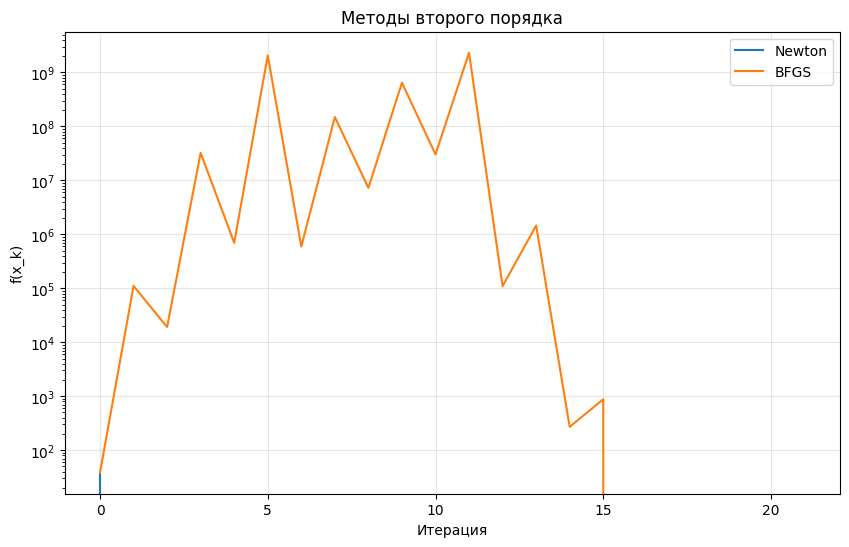

In [9]:
# Задание 5: Методы второго порядка
# На квадратичной задаче из Задания 1

# Создаем задачу заново для размерности 10
d_quad = 10
kappa_quad = 100
f_quad_5, grad_quad_5, hess_quad_5, Q_quad, b_quad = create_quadratic_problem(d_quad, kappa_quad)
x_opt_quad = -np.linalg.inv(Q_quad) @ b_quad

def newton_method(grad_f, hess_f, x0, max_iters=100, tol=1e-12):
    x = x0.copy()
    losses = [f_quad_5(x)]
    for k in range(max_iters):
        grad = grad_f(x)
        hess = hess_f(x)
        if np.linalg.det(hess) == 0:
            break
        x = x - np.linalg.inv(hess) @ grad
        loss = f_quad_5(x)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return x, losses

def bfgs(grad_f, x0, max_iters=100, tol=1e-12):
    x = x0.copy()
    n = len(x)
    B = np.eye(n)  # Approximation of inverse Hessian
    losses = [f_quad_5(x)]
    for k in range(max_iters):
        grad = grad_f(x)
        if np.linalg.norm(grad) < tol:
            break
        try:
            p = -np.linalg.inv(B) @ grad
        except:
            p = -grad  # Fallback to GD
        x_new = x + p
        grad_new = grad_f(x_new)
        s = x_new - x
        y = grad_new - grad
        sy = np.dot(s, y)
        if sy > 1e-10:  # Update B
            Bs = B @ s
            B = B - np.outer(Bs, Bs) / (s @ Bs) + np.outer(y, y) / sy
        x = x_new
        loss = f_quad_5(x)
        losses.append(loss)
    return x, losses

# Используем x0 для квадратичной задачи
x0_quad = np.random.randn(d_quad)

# Запуск методов второго порядка
second_order_methods = {
    'Newton': lambda: newton_method(grad_quad_5, hess_quad_5, x0_quad),
    'BFGS': lambda: bfgs(grad_quad_5, x0_quad)
}

second_results = {}
for name, method in second_order_methods.items():
    x_opt, losses = method()
    second_results[name] = losses
    final_loss = losses[-1]
    distance = np.linalg.norm(x_opt - x_opt_quad)
    print(f"{name}: Final loss = {final_loss:.2e}, Distance to opt = {distance:.2e}")

# Визуализация
plt.figure(figsize=(10, 6))
for name, losses in second_results.items():
    plt.semilogy(losses, label=name)
plt.xlabel('Итерация')
plt.ylabel('f(x_k)')
plt.title('Методы второго порядка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()